<a href="https://colab.research.google.com/github/Foysal061/EmergencyDepartmentPatientPred/blob/main/LightGBM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
#pip install openmeteo-requests requests-cache retry-requests numpy pandas tensorflow scikit-learn
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from datetime import datetime, timedelta
import openmeteo_requests
import requests_cache
from retry_requests import retry
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import json
import warnings
warnings.filterwarnings('ignore')

In [20]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# File paths (MODIFY THESE FOR YOUR SETUP)
ED_DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/VestfoldTriageReport.csv"
INFECTION_DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/Infeksjonsdata.xlsx"

# Hospital coordinates (Vestfold Hospital, Tønsberg)
HOSPITAL_LAT = 59.2725
HOSPITAL_LON = 10.4184

# Feature engineering
USE_LAG_FEATURES = True

In [21]:
def load_ed_data(filepath, separator=';'):
    """Load ED data from CSV"""
    print("\n[1/10] Loading ED data...")
    df = pd.read_csv(filepath, sep=separator)
    df.columns = ['arrival', 'departure', 'first_doctor_response', 'first_triage']
    print(f"   Loaded {len(df)} records")
    print("\nFirst 5 rows:")
    print(df.head())
    return df

# Load data
df = load_ed_data(ED_DATA_PATH)

print("\nData shape:", df.shape)
print("Columns:", df.columns.tolist())


[1/10] Loading ED data...
   Loaded 35674 records

First 5 rows:
            arrival         departure first_doctor_response   first_triage
0  01.10.2023 13:46  06.10.2023 18:10            LessUrgent  Resuscitation
1  01.10.2023 14:20  20.10.2023 11:37            LessUrgent     LessUrgent
2  01.10.2023 13:59  03.10.2023 12:04                   NaN  Resuscitation
3  01.10.2023 14:40  01.10.2023 17:30            LessUrgent     LessUrgent
4  01.10.2023 13:50  01.10.2023 20:45             NotUrgent         Urgent

Data shape: (35674, 4)
Columns: ['arrival', 'departure', 'first_doctor_response', 'first_triage']


In [22]:
def parse_datetime_columns(df):
    """Parse and convert datetime columns"""
    print("\n[2/10] Parsing datetime fields...")

    df['arrival'] = pd.to_datetime(df['arrival'], format='%d.%m.%Y %H:%M', errors='coerce')
    df['departure'] = pd.to_datetime(df['departure'], format='%d.%m.%Y %H:%M', errors='coerce')

    df = df.dropna(subset=['arrival', 'departure'])
    df = df.sort_values('arrival')

    local_zone = 'Europe/Oslo'
    df['arrival'] = df['arrival'].dt.tz_localize(local_zone).dt.tz_convert('UTC').dt.tz_localize(None)
    df['departure'] = df['departure'].dt.tz_localize(local_zone).dt.tz_convert('UTC').dt.tz_localize(None)

    df['duration_hour'] = (df['departure'] - df['arrival']).dt.total_seconds() / (60*60)

    print(f"   Parsed {len(df)} records")
    print(f"   Date range: {df['arrival'].min()} to {df['arrival'].max()}")
    return df

df = parse_datetime_columns(df)

print("\nSample data after parsing:")
print(df.head())


[2/10] Parsing datetime fields...
   Parsed 35674 records
   Date range: 2023-10-01 11:46:00 to 2024-10-25 10:35:00

Sample data after parsing:
              arrival           departure first_doctor_response  \
0 2023-10-01 11:46:00 2023-10-06 16:10:00            LessUrgent   
4 2023-10-01 11:50:00 2023-10-01 18:45:00             NotUrgent   
7 2023-10-01 11:59:00 2023-10-05 13:05:00                Urgent   
2 2023-10-01 11:59:00 2023-10-03 10:04:00                   NaN   
8 2023-10-01 12:20:00 2023-10-02 12:01:00            LessUrgent   

    first_triage  duration_hour  
0  Resuscitation     124.400000  
4         Urgent       6.916667  
7  Resuscitation      97.100000  
2  Resuscitation      46.083333  
8  Resuscitation      23.683333  


In [23]:
def aggregate_to_hourly(df):
    """Aggregate data to hourly intervals"""
    print("\n[3/10] Aggregating to hourly intervals...")

    df['arrival_hour'] = df['arrival'].dt.floor('H')

    hourly_df = df.groupby('arrival_hour').agg({
        'arrival': 'count',
        'duration_hour': ['mean', 'std']
    })

    hourly_df.columns = ['arrival_count', 'duration_mean', 'duration_std']
    hourly_df = hourly_df.reset_index()
    hourly_df[['duration_mean', 'duration_std']] = hourly_df[['duration_mean', 'duration_std']].fillna(0)
    hourly_df['first_doctor_response'] = df['first_doctor_response'].fillna('Unknown')
    hourly_df['first_triage'] = df['first_triage'].fillna('Unknown')

    print(f"   Created {len(hourly_df)} hourly records")
    return hourly_df

df = aggregate_to_hourly(df)

print("\nHourly aggregated data:")
print(df.head(10))


[3/10] Aggregating to hourly intervals...
   Created 8284 hourly records

Hourly aggregated data:
         arrival_hour  arrival_count  duration_mean  duration_std  \
0 2023-10-01 11:00:00              4      68.625000     52.401404   
1 2023-10-01 12:00:00              6     103.847222    174.344335   
2 2023-10-01 13:00:00              6      54.219444     71.494779   
3 2023-10-01 14:00:00              3      11.183333     12.190809   
4 2023-10-01 15:00:00              6     110.741667    110.665416   
5 2023-10-01 16:00:00              3       3.961111      1.736242   
6 2023-10-01 17:00:00              2      20.550000      2.734146   
7 2023-10-01 18:00:00              5      76.573333     69.082435   
8 2023-10-01 19:00:00              4      76.704167    104.066427   
9 2023-10-01 20:00:00              2     124.100000     87.186266   

  first_doctor_response   first_triage  
0            LessUrgent  Resuscitation  
1            LessUrgent     LessUrgent  
2               Un

In [24]:
def fetch_weather_data(start_date, end_date):
    """Fetch weather data from Open-Meteo API in UTC timezone"""
    print(f"\n[4/10] Fetching weather data...")

    cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
    retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
    openmeteo = openmeteo_requests.Client(session=retry_session)

    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": HOSPITAL_LAT,
        "longitude": HOSPITAL_LON,
        "start_date": start_date,
        "end_date": end_date,
        "timezone": "UTC",  # Set timezone to UTC
        "hourly": ["temperature_2m", "relative_humidity_2m", "precipitation",
                  "surface_pressure", "wind_speed_10m"]
    }

    responses = openmeteo.weather_api(url, params=params)
    response = responses[0]
    hourly = response.Hourly()

    timestamps = pd.date_range(
        start=pd.to_datetime(hourly.Time(), unit="s"),
        end=pd.to_datetime(hourly.TimeEnd(), unit="s"),
        freq=pd.Timedelta(seconds=hourly.Interval()),
        inclusive="left"
    )

    weather_df = pd.DataFrame({
        "date": timestamps,
        "temperature": hourly.Variables(0).ValuesAsNumpy().astype(float).round(2),
        "humidity": hourly.Variables(1).ValuesAsNumpy().astype(float).round(2),
        "precipitation": hourly.Variables(2).ValuesAsNumpy().astype(float).round(2),
        "pressure": hourly.Variables(3).ValuesAsNumpy().astype(float).round(2),
        "wind_speed": hourly.Variables(4).ValuesAsNumpy().astype(float).round(2)
    })

    weather_df['date'] = pd.to_datetime(weather_df['date']).dt.tz_localize(None)
    print(f"   Fetched {len(weather_df)} weather records")
    print(f"   Timezone: UTC")
    return weather_df

# Fetch weather data (adjust dates based on your data)
weather_df = fetch_weather_data("2023-01-10", "2024-10-26")

print("\nWeather data sample:")
print(weather_df.head())


[4/10] Fetching weather data...
   Fetched 15744 weather records
   Timezone: UTC

Weather data sample:
                 date  temperature  humidity  precipitation  pressure  \
0 2023-01-10 00:00:00         1.40     98.58            0.0    995.77   
1 2023-01-10 01:00:00         1.65     98.93            0.0    996.47   
2 2023-01-10 02:00:00         1.85     97.53            0.0    997.27   
3 2023-01-10 03:00:00         1.70     96.48            0.0    997.77   
4 2023-01-10 04:00:00         0.55     98.92            0.0    998.36   

   wind_speed  
0        6.88  
1        7.42  
2        7.93  
3        5.62  
4        3.32  


In [25]:
def merge_weather_data(df, weather_df):
    """Merge weather data with ED data"""
    print("\n[5/10] Merging weather data...")

    df['arrival_hour'] = pd.to_datetime(df['arrival_hour'])
    weather_df['date'] = pd.to_datetime(weather_df['date'])

    merged_df = pd.merge_asof(
        df.sort_values("arrival_hour"),
        weather_df.sort_values("date"),
        left_on="arrival_hour",
        right_on="date",
        direction="nearest"
    )

    merged_df = merged_df.drop(columns=['date'], errors='ignore')
    print(f"   Merged to {len(merged_df)} records")
    print(f"   Total columns: {len(merged_df.columns)}")
    return merged_df

df = merge_weather_data(df, weather_df)

print("\nMerged data sample:")
print(df.head())


[5/10] Merging weather data...
   Merged to 8284 records
   Total columns: 11

Merged data sample:
         arrival_hour  arrival_count  duration_mean  duration_std  \
0 2023-10-01 11:00:00              4      68.625000     52.401404   
1 2023-10-01 12:00:00              6     103.847222    174.344335   
2 2023-10-01 13:00:00              6      54.219444     71.494779   
3 2023-10-01 14:00:00              3      11.183333     12.190809   
4 2023-10-01 15:00:00              6     110.741667    110.665416   

  first_doctor_response   first_triage  temperature  humidity  precipitation  \
0            LessUrgent  Resuscitation        15.90     65.10            0.0   
1            LessUrgent     LessUrgent        14.90     58.57            0.0   
2               Unknown  Resuscitation        15.05     59.01            0.0   
3            LessUrgent     LessUrgent        14.50     63.26            0.0   
4             NotUrgent         Urgent        13.65     66.62            0.0   

   p

In [26]:
def load_merge_infection_data(df):
    """Load and merge infection data - convert to hourly averages"""
    print("\n[6/10] Loading infection data...")

    monthly_df = pd.read_excel(INFECTION_DATA_PATH, header=0)

    print(f"   Loaded {len(monthly_df)} months of infection data")
    print(f"   Columns: {list(monthly_df.columns)}")
    print("\n   Sample infection data:")
    print(monthly_df.head())

    # Parse Month column
    monthly_df['Month'] = pd.to_datetime(monthly_df['Month'], format='%b-%y')

    # Create year_month for merging
    df['year_month'] = df['arrival_hour'].dt.to_period('M')
    monthly_df['year_month'] = monthly_df['Month'].dt.to_period('M')

    # Merge
    df_merged = df.merge(
        monthly_df[['year_month', 'Total_Infected_Patient_Monthly']],
        on='year_month',
        how='left'
    )

    # Convert to hourly averages
    print(f"\n   Converting monthly infection counts to hourly averages...")
    hours_in_month = df_merged['arrival_hour'].dt.days_in_month * 24
    df_merged['infection_rate_hourly'] = (
        df_merged['Total_Infected_Patient_Monthly'] / hours_in_month
    )

    # Drop temporary columns
    df_merged = df_merged.drop(columns=['Total_Infected_Patient_Monthly', 'year_month'])

    print(f"   Created 'infection_rate_hourly' feature")


    return df_merged

df = load_merge_infection_data(df)

print("\nData with infection rates:")
print(df.head(10))


[6/10] Loading infection data...
   Loaded 24 months of infection data
   Columns: ['Month', 'Total_Infected_Patient_Monthly']

   Sample infection data:
       Month  Total_Infected_Patient_Monthly
0 2023-10-01                             616
1 2023-11-01                             924
2 2023-12-01                            1175
3 2024-01-01                            1026
4 2024-02-01                            1163

   Converting monthly infection counts to hourly averages...
   Created 'infection_rate_hourly' feature

Data with infection rates:
         arrival_hour  arrival_count  duration_mean  duration_std  \
0 2023-10-01 11:00:00              4      68.625000     52.401404   
1 2023-10-01 12:00:00              6     103.847222    174.344335   
2 2023-10-01 13:00:00              6      54.219444     71.494779   
3 2023-10-01 14:00:00              3      11.183333     12.190809   
4 2023-10-01 15:00:00              6     110.741667    110.665416   
5 2023-10-01 16:00:00       

In [27]:
def fetch_norwegian_holidays(start_year, end_year):
    """Fetch Norwegian public holidays"""
    print(f"\n[7/10] Fetching Norwegian holidays {start_year}-{end_year}...")

    all_holidays = []
    for year in range(start_year, end_year + 1):
        try:
            url = f"https://date.nager.at/api/v3/PublicHolidays/{year}/NO"
            response = requests.get(url, timeout=10)
            if response.status_code == 200:
                holidays = response.json()
                for holiday in holidays:
                    all_holidays.append({'date': pd.to_datetime(holiday['date'])})
                print(f"     {year}: {len(holidays)} holidays")
        except:
            print(f"     {year}: Failed")

    if not all_holidays:
        return pd.DataFrame(columns=['date'])

    holidays_df = pd.DataFrame(all_holidays).drop_duplicates(subset=['date'])
    print(f"   Total: {len(holidays_df)} unique holidays")
    return holidays_df

def add_holiday_feature(df):
    """Add is_holiday feature"""
    start_year = df['arrival_hour'].dt.year.min()
    end_year = df['arrival_hour'].dt.year.max()

    holidays_df = fetch_norwegian_holidays(start_year, end_year)

    if holidays_df.empty:
        df['is_holiday'] = 0
    else:
        df['_date'] = pd.to_datetime(df['arrival_hour']).dt.date
        holidays_df['_date'] = holidays_df['date'].dt.date
        holiday_dates = set(holidays_df['_date'])
        df['is_holiday'] = df['_date'].isin(holiday_dates).astype(int)
        df = df.drop(columns=['_date'])

    n_holidays = df['is_holiday'].sum()
    print(f"   Holiday hours: {n_holidays} ({n_holidays/len(df)*100:.1f}%)")

    return df

df = add_holiday_feature(df)

print("\nData with holiday feature:")
print(df[['arrival_hour', 'arrival_count', 'is_holiday']].head(20))


[7/10] Fetching Norwegian holidays 2023-2024...
     2023: 12 holidays
     2024: 12 holidays
   Total: 24 unique holidays
   Holiday hours: 259 (3.1%)

Data with holiday feature:
          arrival_hour  arrival_count  is_holiday
0  2023-10-01 11:00:00              4           0
1  2023-10-01 12:00:00              6           0
2  2023-10-01 13:00:00              6           0
3  2023-10-01 14:00:00              3           0
4  2023-10-01 15:00:00              6           0
5  2023-10-01 16:00:00              3           0
6  2023-10-01 17:00:00              2           0
7  2023-10-01 18:00:00              5           0
8  2023-10-01 19:00:00              4           0
9  2023-10-01 20:00:00              2           0
10 2023-10-01 21:00:00              1           0
11 2023-10-01 22:00:00              1           0
12 2023-10-01 23:00:00              1           0
13 2023-10-02 02:00:00              1           0
14 2023-10-02 03:00:00              1           0
15 2023-10-02 04:00

In [28]:
def create_temporal_features(df):
    """Create temporal features"""
    print("\n[8/10] Creating temporal features...")

    df['hour'] = df['arrival_hour'].dt.hour
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    df['day'] = df['arrival_hour'].dt.day
    df['dayofweek'] = df['arrival_hour'].dt.dayofweek
    df['week'] = df['arrival_hour'].dt.isocalendar().week
    df['month'] = df['arrival_hour'].dt.month
    df['year'] = df['arrival_hour'].dt.year
    df['day_of_year'] = df['arrival_hour'].dt.dayofyear
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    df['is_monday'] = (df['dayofweek'] == 0).astype(int)
    df['is_friday'] = (df['dayofweek'] == 4).astype(int)
    df['day_sin'] = np.sin(2 * np.pi * df['day'] / 31)
    df['day_cos'] = np.cos(2 * np.pi * df['day'] / 31)
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    df['week_sin'] = np.sin(2 * np.pi * df['week'] / 52)
    df['week_cos'] = np.cos(2 * np.pi * df['week'] / 52)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
        # Time of day categories
    df['time_of_day'] = pd.cut(
        df['hour'],
        bins=[-1, 6, 12, 18, 24],
        labels=['night', 'morning', 'afternoon', 'evening']
    )

    # Shift patterns
    df['shift'] = pd.cut(
        df['hour'],
        bins=[-1, 8, 16, 24],
        labels=['night_shift', 'day_shift', 'evening_shift']
    )
    df['same_hour_last_week'] = df['arrival_count'].shift(168)
    df['same_hour_2weeks_ago'] = df['arrival_count'].shift(336)
    df['diff_from_last_week'] = (
        df['arrival_count'] - df['same_hour_last_week']
    )
    df['arrival_change_1h'] = df['arrival_count'].diff(1)
    df['arrival_change_3h'] = df['arrival_count'].diff(3)
    df['arrival_pct_change_1h'] = df['arrival_count'].pct_change(1)
    df['arrival_pct_change_24h'] = df['arrival_count'].pct_change(24)
    df['ema_12h'] = df['arrival_count'].ewm(span=12).mean()
    df['ema_24h'] = df['arrival_count'].ewm(span=24).mean()

    print(f"   Created temporal features")
    return df

df = create_temporal_features(df)

print(f"\nTotal columns now: {len(df.columns)}")
print("Temporal features:")
temporal_cols = [col for col in df.columns if any(x in col for x in ['hour', 'day', 'week', 'month', 'sin', 'cos'])]
print(temporal_cols)


[8/10] Creating temporal features...
   Created temporal features

Total columns now: 44
Temporal features:
['arrival_hour', 'infection_rate_hourly', 'is_holiday', 'hour', 'hour_sin', 'hour_cos', 'day', 'dayofweek', 'week', 'month', 'day_of_year', 'is_weekend', 'is_monday', 'is_friday', 'day_sin', 'day_cos', 'dayofweek_sin', 'dayofweek_cos', 'week_sin', 'week_cos', 'month_sin', 'month_cos', 'time_of_day', 'same_hour_last_week', 'same_hour_2weeks_ago', 'diff_from_last_week']


In [29]:
def create_lag_features(df, target_col='arrival_count', lags=[1, 6, 12, 24]):
    """Create lag features"""
    print(f"\n   Creating lag features for {target_col}...")
    for lag in lags:
        df[f'{target_col}_lag_{lag}'] = df[target_col].shift(lag)
    df[f'{target_col}_next'] = df[target_col].shift(-1)
    df = df.dropna()
    print(f"   Created lag features: {lags}")
    return df

df = create_lag_features(df, 'arrival_count', [1, 6, 12, 24])

print(f"Data shape after lag features: {df.shape}")
print(f"\nLag features created:")
lag_cols = [col for col in df.columns if 'lag' in col]
print(lag_cols)


   Creating lag features for arrival_count...
   Created lag features: [1, 6, 12, 24]
Data shape after lag features: (7947, 49)

Lag features created:
['arrival_count_lag_1', 'arrival_count_lag_6', 'arrival_count_lag_12', 'arrival_count_lag_24']


In [30]:
def encode_categorical_for_lightgbm(hourly_df):

    print("\nEncoding categorical variables for LightGBM...")

    categorical_cols = [col for col in ['first_doctor_response', 'first_triage',
                                         'time_of_day', 'shift', 'is_weekend', 'is_monday', 'is_friday']
                       if col in hourly_df.columns]

    for col in categorical_cols:
        hourly_df[col] = hourly_df[col].astype('category')

    print(f"Converted {len(categorical_cols)} columns to category dtype")
    print(f"   Columns: {categorical_cols}")

    print(hourly_df["time_of_day"].tail())
    return hourly_df, categorical_cols

df, categorical_features = encode_categorical_for_lightgbm(df)



Encoding categorical variables for LightGBM...
Converted 7 columns to category dtype
   Columns: ['first_doctor_response', 'first_triage', 'time_of_day', 'shift', 'is_weekend', 'is_monday', 'is_friday']
8278    evening
8279      night
8280      night
8281    morning
8282    morning
Name: time_of_day, dtype: category
Categories (4, object): ['night' < 'morning' < 'afternoon' < 'evening']


In [31]:
def create_target_variable(hourly_df, horizon=1):
    print(f"\n Creating target variable (horizon={horizon} hours)...")

    hourly_df['target'] = hourly_df['arrival_count_next']
    hourly_df = hourly_df.dropna(subset=['target'])

    print(f"Target created! Final shape: {hourly_df.shape}")
    return hourly_df
df = create_target_variable(df)
print(df[['hour','arrival_count','target']])



 Creating target variable (horizon=1 hours)...
Target created! Final shape: (7947, 50)
      hour  arrival_count  target
336      5              2     5.0
337      6              5     8.0
338      7              8     6.0
339      8              6     5.0
340      9              5     6.0
...    ...            ...     ...
8278    22              2     2.0
8279     5              2     1.0
8280     6              1     2.0
8281     7              2     2.0
8282     9              2     1.0

[7947 rows x 3 columns]


In [32]:
def prepare_train_test_split(hourly_df, test_size=0.2):

    print("\n" + "="*60)
    print("PREPARING TRAIN/TEST SPLIT")
    print("="*60)

    # Separate features and target
    feature_cols = [col for col in hourly_df.columns
                   if col not in ['target', 'arrival_hour', 'arrival_count','arrival_count_next']]

    X = hourly_df[feature_cols]
    y = hourly_df['target']

    # Chronological split
    split_idx = int(len(hourly_df) * (1 - test_size))

    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]

    train_dates = hourly_df['arrival_hour'].iloc[:split_idx]
    test_dates = hourly_df['arrival_hour'].iloc[split_idx:]

    print(f"\nTrain set:")
    print(f"   Size: {len(X_train)} samples")
    print(f"   Date range: {train_dates.min()} to {train_dates.max()}")

    print(f"\nTest set:")
    print(f"   Size: {len(X_test)} samples")
    print(f"   Date range: {test_dates.min()} to {test_dates.max()}")

    print(f"\nFeatures: {len(feature_cols)}")

    return X_train, X_test, y_train, y_test, test_dates, feature_cols

X_train, X_test, y_train, y_test, test_dates, feature_cols = prepare_train_test_split(df)



PREPARING TRAIN/TEST SPLIT

Train set:
   Size: 6357 samples
   Date range: 2023-10-17 05:00:00 to 2024-08-11 00:00:00

Test set:
   Size: 1590 samples
   Date range: 2024-08-11 01:00:00 to 2024-10-25 09:00:00

Features: 46


In [33]:
import lightgbm as lgb
def train_lightgbm_model(X_train, y_train, X_test, y_test,categorical_features):
    print("\n" + "="*60)
    print("TRAINING LIGHTGBM MODEL")
    print("="*60)

    # LightGBM parameters
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'num_leaves': 31,
        'learning_rate': 0.05,
        'feature_fraction': 0.9,
        'bagging_fraction': 0.8,
        'bagging_freq': 5,
        'verbose': -1,
        'max_depth': -1,
        'min_data_in_leaf': 20,
        'lambda_l1': 0.1,
        'lambda_l2': 0.1
    }

    # Create datasets
    train_data = lgb.Dataset(X_train, label=y_train, categorical_feature= categorical_features)
    test_data = lgb.Dataset(X_test, label=y_test, reference=train_data, categorical_feature= categorical_features)

    # Train model
    print("\nTraining in progress...")
    model = lgb.train(
        params,
        train_data,
        num_boost_round=1000,
        valid_sets=[train_data, test_data],
        valid_names=['train', 'valid'],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50),
            lgb.log_evaluation(period=100)
        ]
    )

    print(f"\nTraining complete!")
    print(f"Best iteration: {model.best_iteration}")
    print(f"Best score: {model.best_score['valid']['rmse']:.4f}")

    return model

model = train_lightgbm_model(X_train, y_train, X_test, y_test, categorical_features)


TRAINING LIGHTGBM MODEL

Training in progress...
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 1.83605	valid's rmse: 2.43921
Early stopping, best iteration is:
[57]	train's rmse: 1.99195	valid's rmse: 2.42955

Training complete!
Best iteration: 57
Best score: 2.4296


In [34]:
def mean_absolute_percentage_error(y_true, y_pred):
    """Compute MAPE (Mean Absolute Percentage Error)"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    non_zero_idx = y_true != 0
    return np.mean(np.abs((y_true[non_zero_idx] - y_pred[non_zero_idx]) / y_true[non_zero_idx])) * 100


def evaluate_model(model, X_train, y_train, X_test, y_test):
    print("\n" + "="*60)
    print("MODEL EVALUATION")
    print("="*60)

    # Predictions
    y_train_pred = model.predict(X_train, num_iteration=model.best_iteration)
    y_test_pred = model.predict(X_test, num_iteration=model.best_iteration)

    # Train metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    train_mape = mean_absolute_percentage_error(y_train, y_train_pred)

    # Test metrics
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)
    test_mape = mean_absolute_percentage_error(y_test, y_test_pred)

    # Display results
    print("\nTrain Set Metrics:")
    print(f"   MAE:  {train_mae:.4f}")
    print(f"   RMSE: {train_rmse:.4f}")
    print(f"   R²:   {train_r2:.4f}")
    print(f"   MAPE: {train_mape:.2f}%")

    print("\nTest Set Metrics:")
    print(f"   MAE:  {test_mae:.4f}")
    print(f"   RMSE: {test_rmse:.4f}")
    print(f"   R²:   {test_r2:.4f}")
    print(f"   MAPE: {test_mape:.2f}%")

    return y_train_pred, y_test_pred, {
        'train': {'mae': train_mae, 'rmse': train_rmse, 'r2': train_r2, 'mape': train_mape},
        'test': {'mae': test_mae, 'rmse': test_rmse, 'r2': test_r2, 'mape': test_mape}
    }

# Example usage
y_train_pred, y_test_pred, metrics = evaluate_model(model, X_train, y_train, X_test, y_test)



MODEL EVALUATION

Train Set Metrics:
   MAE:  1.4403
   RMSE: 1.9919
   R²:   0.5782
   MAPE: 53.60%

Test Set Metrics:
   MAE:  1.7857
   RMSE: 2.4296
   R²:   0.4011
   MAPE: 64.51%


In [35]:
# =============================================================================
# MULTI-STEP FORECAST EVALUATION (MATCHING LSTM FORMAT)
# =============================================================================

print("\n" + "="*80)
print("MULTI-STEP FORECAST EVALUATION")
print("="*80)

HORIZONS = [1, 2, 6, 12, 24]

def multi_step_forecast_lgbm(model, start_features, feature_cols,
                              categorical_features, horizon):
    """
    Autoregressive multi-step forecast for LightGBM.
    Predict 1 hour at a time, update features, repeat.
    """
    feat_idx = {col: i for i, col in enumerate(feature_cols)}
    current_features = start_features.copy()
    predictions = []

    for step in range(horizon):
        # Predict next 1 hour
        feat_df = pd.DataFrame([current_features], columns=feature_cols)
        for col in categorical_features:
            if col in feat_df.columns:
                feat_df[col] = feat_df[col].astype('category')

        y_pred = model.predict(feat_df, num_iteration=model.best_iteration)[0]
        y_pred = max(0, y_pred)
        predictions.append(y_pred)

        # --- Update features for next step ---
        new_features = current_features.copy()

        # Update lag features
        lag_map = {'arrival_count_lag_1': 1, 'arrival_count_lag_6': 6,
                   'arrival_count_lag_12': 12, 'arrival_count_lag_24': 24}

        for lag_col, lag_num in lag_map.items():
            if lag_col in feat_idx:
                steps_back = step + 1 - lag_num
                if 0 <= steps_back < len(predictions):
                    new_features[feat_idx[lag_col]] = predictions[steps_back]

        # Update temporal features
        if 'hour' in feat_idx:
            current_hour = int(new_features[feat_idx['hour']])
            next_hour = (current_hour + 1) % 24

            new_features[feat_idx['hour']] = next_hour

            if 'hour_sin' in feat_idx:
                new_features[feat_idx['hour_sin']] = np.sin(2 * np.pi * next_hour / 24)
            if 'hour_cos' in feat_idx:
                new_features[feat_idx['hour_cos']] = np.cos(2 * np.pi * next_hour / 24)

            # Time of day: night=0, morning=1, afternoon=2, evening=3
            if 'time_of_day' in feat_idx:
                if next_hour <= 6:
                    new_features[feat_idx['time_of_day']] = 0
                elif next_hour <= 12:
                    new_features[feat_idx['time_of_day']] = 1
                elif next_hour <= 18:
                    new_features[feat_idx['time_of_day']] = 2
                else:
                    new_features[feat_idx['time_of_day']] = 3

            # Shift: night=0, day=1, evening=2
            if 'shift' in feat_idx:
                if next_hour <= 8:
                    new_features[feat_idx['shift']] = 0
                elif next_hour <= 16:
                    new_features[feat_idx['shift']] = 1
                else:
                    new_features[feat_idx['shift']] = 2

            # Day rolls over at midnight
            if next_hour == 0 and 'dayofweek' in feat_idx:
                dow = int(new_features[feat_idx['dayofweek']])
                new_dow = (dow + 1) % 7
                new_features[feat_idx['dayofweek']] = new_dow

                if 'dayofweek_sin' in feat_idx:
                    new_features[feat_idx['dayofweek_sin']] = np.sin(2 * np.pi * new_dow / 7)
                if 'dayofweek_cos' in feat_idx:
                    new_features[feat_idx['dayofweek_cos']] = np.cos(2 * np.pi * new_dow / 7)
                if 'is_weekend' in feat_idx:
                    new_features[feat_idx['is_weekend']] = 1 if new_dow >= 5 else 0
                if 'is_monday' in feat_idx:
                    new_features[feat_idx['is_monday']] = 1 if new_dow == 0 else 0
                if 'is_friday' in feat_idx:
                    new_features[feat_idx['is_friday']] = 1 if new_dow == 4 else 0

        # Update EMA
        if 'ema_12h' in feat_idx:
            alpha_12 = 2 / (12 + 1)
            new_features[feat_idx['ema_12h']] = (
                alpha_12 * y_pred + (1 - alpha_12) * new_features[feat_idx['ema_12h']]
            )
        if 'ema_24h' in feat_idx:
            alpha_24 = 2 / (24 + 1)
            new_features[feat_idx['ema_24h']] = (
                alpha_24 * y_pred + (1 - alpha_24) * new_features[feat_idx['ema_24h']]
            )

        # Update change features
        if 'arrival_change_1h' in feat_idx and len(predictions) >= 2:
            new_features[feat_idx['arrival_change_1h']] = predictions[-1] - predictions[-2]

        if 'arrival_change_3h' in feat_idx and len(predictions) >= 4:
            new_features[feat_idx['arrival_change_3h']] = predictions[-1] - predictions[-4]

        current_features = new_features

    return np.array(predictions)


# --- Evaluate each horizon (same as LSTM: 100 samples, last prediction) ---
results = {}

for horizon in HORIZONS:
    print(f"\n{'='*80}")
    print(f"HORIZON: {horizon} HOUR(S) AHEAD")
    print(f"{'='*80}")

    all_preds, all_acts = [], []
    n_samples = min(100, len(X_test) - horizon)

    for i in range(n_samples):
        start_features = X_test.iloc[i].values

        forecast = multi_step_forecast_lgbm(
            model, start_features, feature_cols,
            categorical_features, horizon
        )

        pred = forecast[-1]  # prediction at the horizon
        actual = y_test.iloc[i + horizon - 1]

        all_preds.append(pred)
        all_acts.append(actual)

    preds = np.array(all_preds)
    acts = np.array(all_acts)

    rmse = np.sqrt(mean_squared_error(acts, preds))
    mae = mean_absolute_error(acts, preds)
    r2 = r2_score(acts, preds)
    mape = np.mean(np.abs((acts - preds) / (acts + 1e-8))) * 100

    results[horizon] = {
        'predictions': preds, 'actuals': acts,
        'rmse': rmse, 'mae': mae, 'r2': r2, 'mape': mape
    }

    print(f"\nMetrics:")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  MAE: {mae:.3f}")
    print(f"  R²: {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")


# --- Summary table ---
results_summary = []
for horizon, data in sorted(results.items()):
    results_summary.append({
        'Horizon': f'{horizon}h',
        'RMSE': f"{data['rmse']:.3f}",
        'MAE': f"{data['mae']:.3f}",
        'R²': f"{data['r2']:.4f}",
        'MAPE': f"{data['mape']:.2f}%"
    })

summary_df = pd.DataFrame(results_summary)
summary_df.to_csv('lgbm_forecast_results.csv', index=False)
print("\n Saved: lgbm_forecast_results.csv")

print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))


MULTI-STEP FORECAST EVALUATION

HORIZON: 1 HOUR(S) AHEAD

Metrics:
  RMSE: 2.319
  MAE: 1.900
  R²: 0.3318
  MAPE: 72.84%

HORIZON: 2 HOUR(S) AHEAD

Metrics:
  RMSE: 2.276
  MAE: 1.835
  R²: 0.3611
  MAPE: 69.77%

HORIZON: 6 HOUR(S) AHEAD

Metrics:
  RMSE: 2.619
  MAE: 2.062
  R²: 0.1452
  MAPE: 65.90%

HORIZON: 12 HOUR(S) AHEAD

Metrics:
  RMSE: 2.639
  MAE: 1.995
  R²: 0.1407
  MAPE: 70.04%

HORIZON: 24 HOUR(S) AHEAD

Metrics:
  RMSE: 3.159
  MAE: 2.430
  R²: -0.0599
  MAPE: 77.59%

 Saved: lgbm_forecast_results.csv

RESULTS SUMMARY
Horizon  RMSE   MAE      R²   MAPE
     1h 2.319 1.900  0.3318 72.84%
     2h 2.276 1.835  0.3611 69.77%
     6h 2.619 2.062  0.1452 65.90%
    12h 2.639 1.995  0.1407 70.04%
    24h 3.159 2.430 -0.0599 77.59%


 Saved: LightGBM_forecast_1h.png


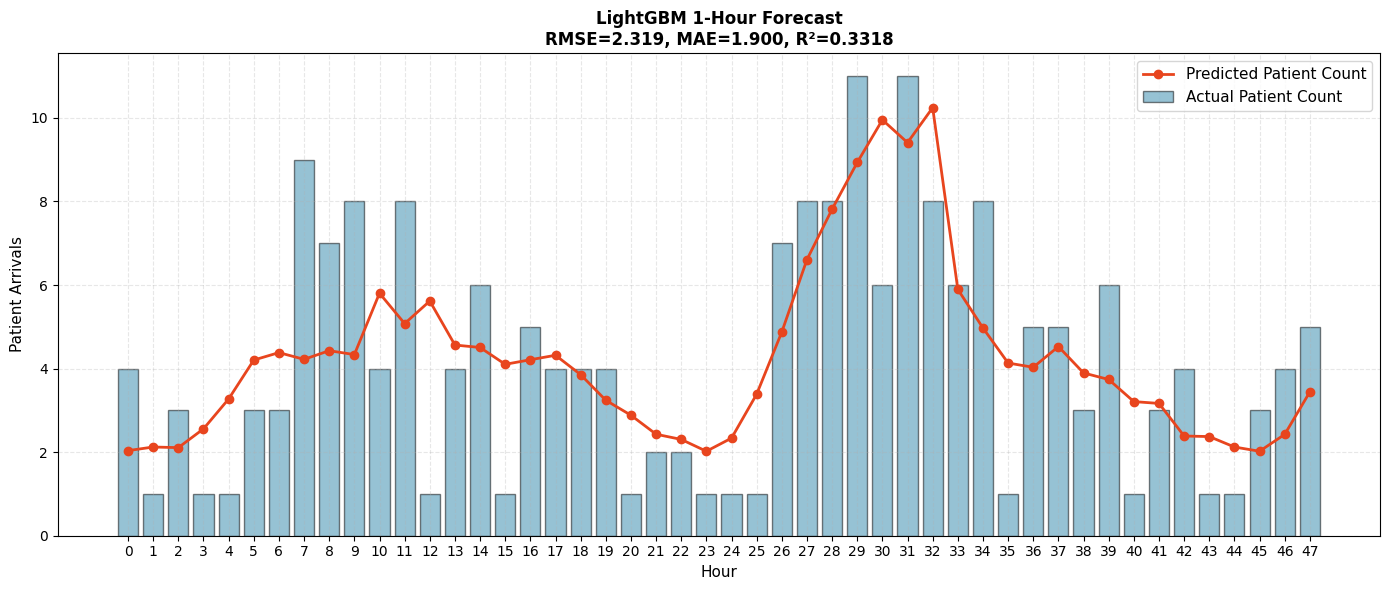

 Saved: LightGBM_forecast_2h.png


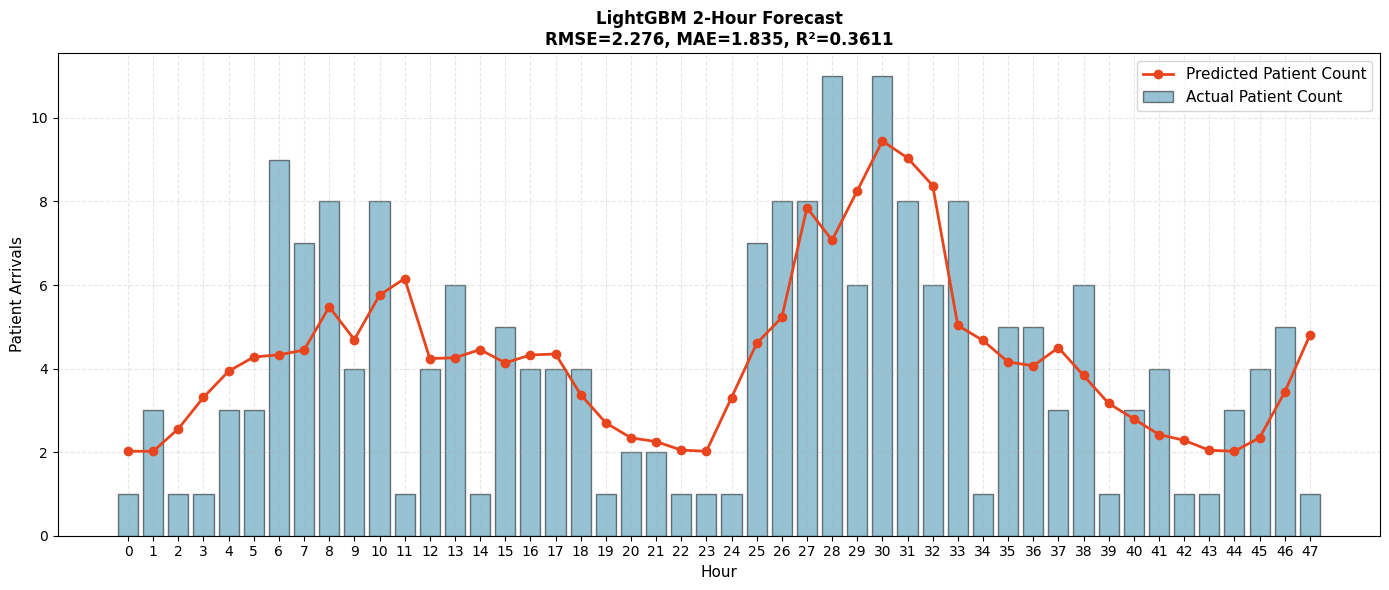

 Saved: LightGBM_forecast_6h.png


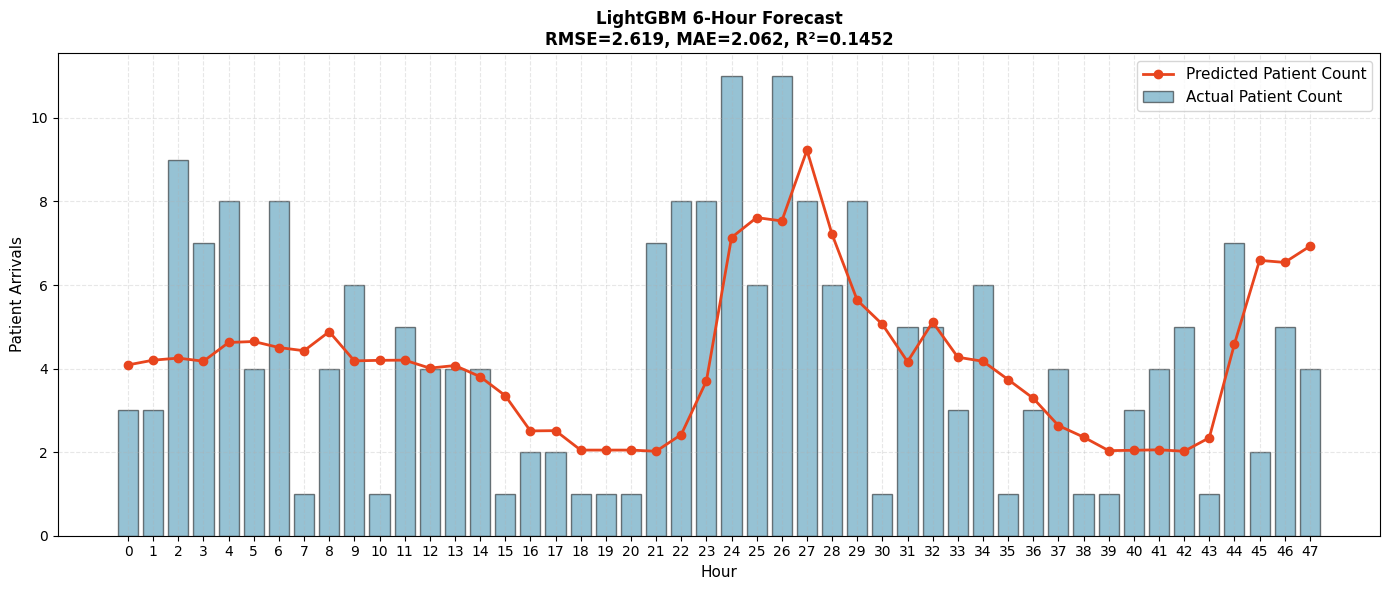

 Saved: LightGBM_forecast_12h.png


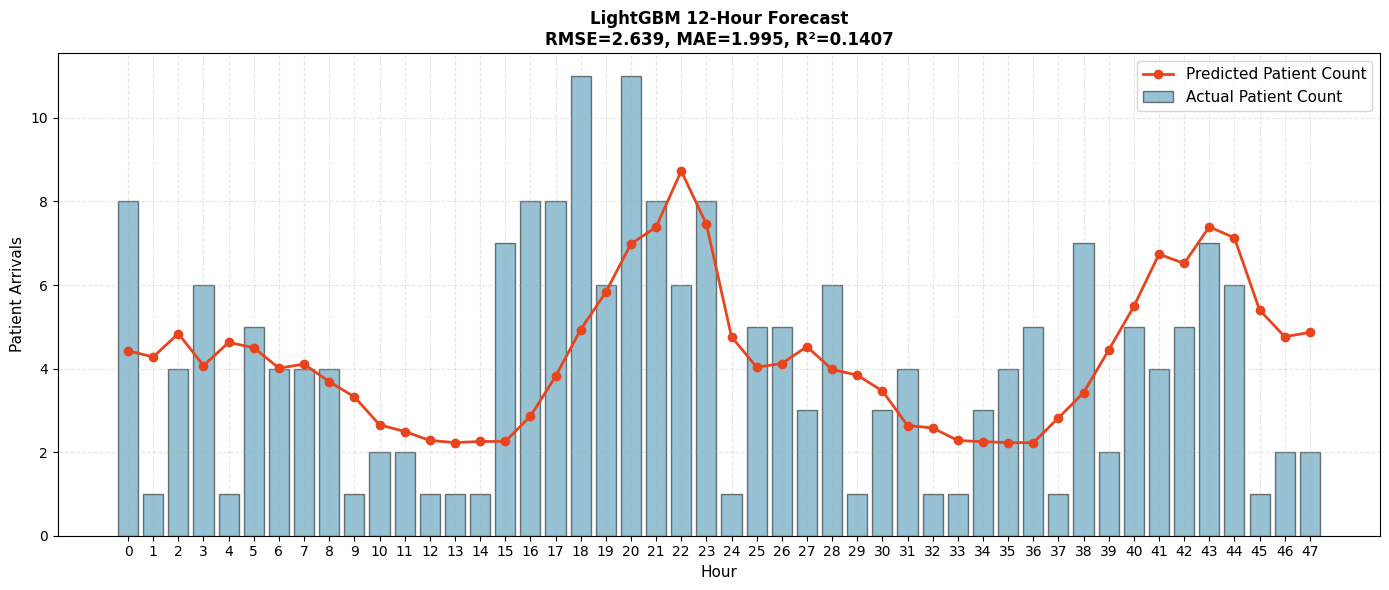

 Saved: LightGBM_forecast_24h.png


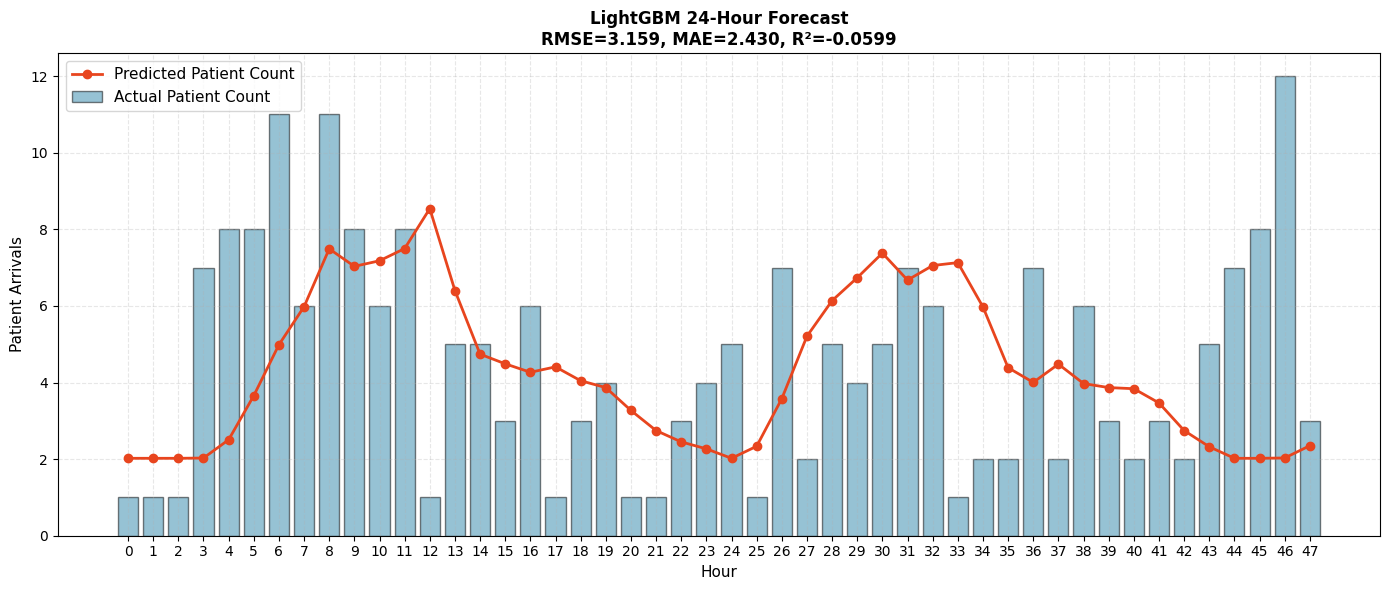

 Saved: LightGBM_feature_importance.png


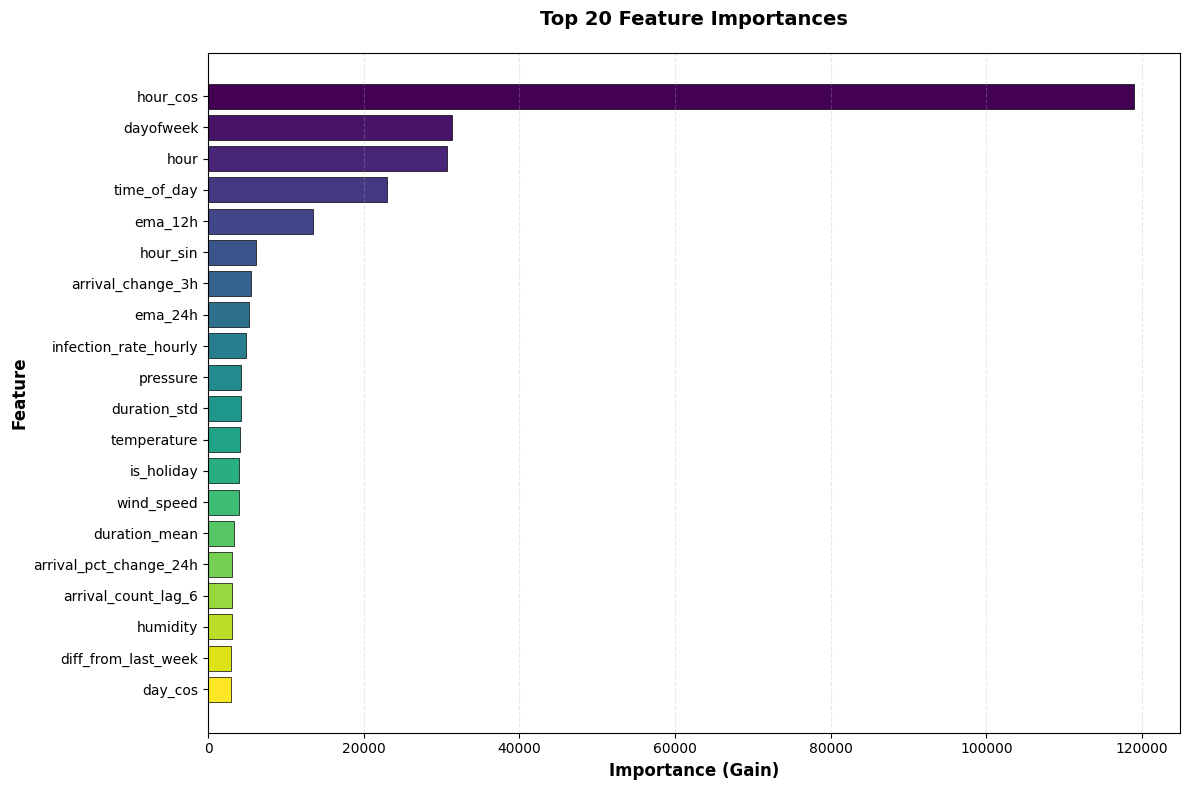


TOP 10 MOST IMPORTANT FEATURES
14. hour_cos                       - Importance: 118,945
16. dayofweek                      - Importance: 31,356
12. hour                           - Importance: 30,660
32. time_of_day                    - Importance: 22,941
41. ema_12h                        - Importance: 13,471
13. hour_sin                       - Importance: 6,211
38. arrival_change_3h              - Importance: 5,519
42. ema_24h                        - Importance: 5,307
10. infection_rate_hourly          - Importance: 4,878
 8. pressure                       - Importance: 4,247

PIPELINE COMPLETE!


In [36]:
# =============================================================================
# VISUALIZATION — SAME FORMAT AS LSTM (one file per horizon)
# =============================================================================



def plot_feature_importance(model, feature_cols, top_n=100):
    """Plot top feature importances"""
    importance = model.feature_importance(importance_type='gain')
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': importance
    }).sort_values('importance', ascending=False)

    fig = plt.figure(figsize=(12, 8))

    top_features = feature_importance.head(top_n)
    colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))

    plt.barh(range(len(top_features)), top_features['importance'].values,
             color=colors, edgecolor='black', linewidth=0.5)
    plt.yticks(range(len(top_features)), top_features['feature'].values)
    plt.xlabel('Importance (Gain)', fontsize=12, fontweight='bold')
    plt.ylabel('Feature', fontsize=12, fontweight='bold')
    plt.title(f'Top {top_n} Feature Importances', fontsize=14, fontweight='bold', pad=20)
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x', linestyle='--')
    plt.tight_layout()

    return fig, feature_importance

for horizon in HORIZONS:
    fig, ax = plt.subplots(figsize=(14, 6))

    preds = results[horizon]['predictions'][:48]
    acts = results[horizon]['actuals'][:48]
    x = np.arange(len(preds))

    ax.bar(x, acts, alpha=0.5, label='Actual Patient Count',
           color='#2E86AB', edgecolor='black')
    ax.plot(x, preds, 'o-', label='Predicted Patient Count',
            color='#E8451E', linewidth=2, markersize=6)

    ax.set_xlabel('Hour', fontsize=11)
    ax.set_ylabel('Patient Arrivals', fontsize=11)
    ax.set_title(f'LightGBM {horizon}-Hour Forecast\n'
                 f'RMSE={results[horizon]["rmse"]:.3f}, '
                 f'MAE={results[horizon]["mae"]:.3f}, '
                 f'R²={results[horizon]["r2"]:.4f}',
                 fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xticks(x)

    plt.tight_layout()
    fig.savefig(f'LightGBM_forecast_{horizon}h.png', dpi=300, bbox_inches='tight')
    print(f" Saved: LightGBM_forecast_{horizon}h.png")
    plt.show()

# Feature importance
fig3, feature_importance_df = plot_feature_importance(model, feature_cols, top_n=20)
fig3.savefig('LightGBM_feature_importance.png', dpi=300, bbox_inches='tight')
print(" Saved: LightGBM_feature_importance.png")
plt.show()

# Top 10 features
print("\n" + "="*60)
print("TOP 10 MOST IMPORTANT FEATURES")
print("="*60)
for idx, row in feature_importance_df.head(10).iterrows():
    print(f"{idx+1:2d}. {row['feature']:30s} - Importance: {row['importance']:,.0f}")
print("="*60)

print("\n" + "="*60)
print("PIPELINE COMPLETE!")
print("="*60)